In [ ]:
!pip install pandas==2.2.2 numpy==1.26.4 \
sentence-transformers==2.7.0 torch==2.3.1 \
scikit-learn==1.4.2 matplotlib==3.8.4


e:\Flutter\saskia\check-plagiat\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
e:\Flutter\saskia\check-plagiat\venv\lib\site-packages\transformers\utils\generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


Jumlah data: 778
                                             title_1  \
0  studi mahasiswa ulama universitas akuntansi su...   
1  darussalam putra baru konawe santri proses pes...   
2  kolaka pajak pendapatan  daerah analisis utara...   

                                          abstract_1  \
0  harga menggunakan konvensional bisnis stok sep...   
1  information memungkinkan fakultas  teknik meng...   
2  sentral  fungsinya di tersebut ramah pembimbin...   

                                             title_2  \
0  khusus kendari  pengambilan jangka menerima ak...   
1  kekuatan negeri kemampuan kelas otot lembing l...   
2  sensor tcs  uno penyimpanan berbasis uang mikr...   

                                          abstract_2  label  
0  results has of building shop manually fact ahm...      0  
1  uji lengan ana  sehingga signifikan nilai smp ...      0  
2  berdasarkan konawe kecelakaan korban  mengguna...      0  


e:\Flutter\saskia\check-plagiat\venv\lib\site-packages\huggingface_hub\file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
e:\Flutter\saskia\check-plagiat\venv\lib\site-packages\transformers\utils\generic.py:309: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(
e:\Flutter\saskia\check-plagiat\venv\lib\site-packages\huggingface_hub\file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


🔄 Encoding teks (mungkin butuh 1–2 menit)...


Batches: 100%|██████████| 25/25 [01:13<00:00,  2.92s/it]


Data train: 622, data test: 156

📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        78
           1       1.00      1.00      1.00        78

    accuracy                           1.00       156
   macro avg       1.00      1.00      1.00       156
weighted avg       1.00      1.00      1.00       156

✅ Accuracy: 1.000
🎯 AUC Score: 1.000


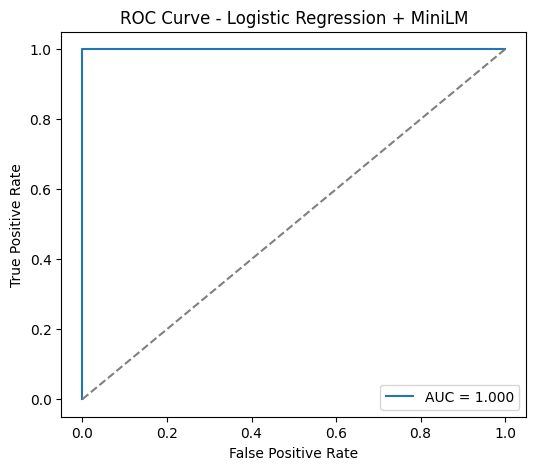

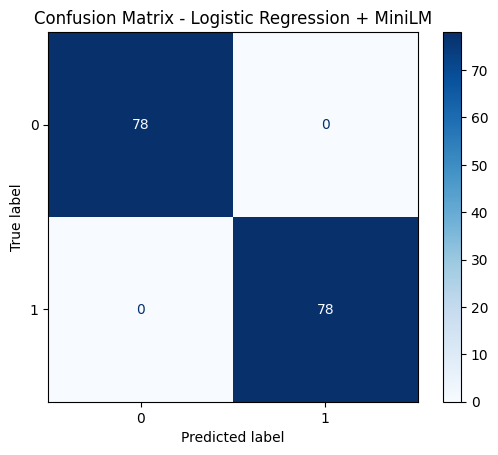

In [1]:
# ===============================================
# 🤖 MODEL FINAL CEK PLAIGIAT – MINI LM + LOGISTIC REGRESSION
# ===============================================

import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
import matplotlib.pyplot as plt

# ===============================================
# 1️⃣ Load Dataset Baru
# ===============================================
df = pd.read_csv("dataset_pairs_generated.csv")
print("Jumlah data:", len(df))
print(df.head(3))

# Gabungkan judul + abstrak jadi satu teks untuk embedding
df['text_1'] = df['title_1'] + ". " + df['abstract_1']
df['text_2'] = df['title_2'] + ". " + df['abstract_2']

# ===============================================
# 2️⃣ Load Model Sentence-BERT (MiniLM)
# ===============================================
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Encode semua teks (gunakan cache jika mau hemat waktu)
print("🔄 Encoding teks (mungkin butuh 1–2 menit)...")
emb1 = model.encode(df['text_1'].tolist(), show_progress_bar=True)
emb2 = model.encode(df['text_2'].tolist(), show_progress_bar=True)

# ===============================================
# 3️⃣ Buat Feature Embedding – perbedaan antar dua teks
# ===============================================
X = np.abs(emb1 - emb2)  # fitur utama: selisih absolut antar embedding
y = df['label'].values

# ===============================================
# 4️⃣ Split Data Training & Testing
# ===============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Data train: {len(X_train)}, data test: {len(X_test)}")

# ===============================================
# 5️⃣ Latih Logistic Regression
# ===============================================
clf = LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear')
clf.fit(X_train, y_train)

# ===============================================
# 6️⃣ Evaluasi Model
# ===============================================
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

print(f"✅ Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"🎯 AUC Score: {roc_auc_score(y_test, y_prob):.3f}")

# ===============================================
# 7️⃣ Visualisasi ROC Curve
# ===============================================
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression + MiniLM")
plt.legend()
plt.show()

# ===============================================
# 8️⃣ Confusion Matrix
# ===============================================
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression + MiniLM")
plt.show()


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model

# Gunakan X_train, y_train, X_test, y_test dari sebelumnya
model_keras = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_keras.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
model_keras.fit(X_train, y_train, epochs=10, batch_size=16, validation_data=(X_test, y_test))

# Simpan model ke HDF5
model_keras.save("plagiarism_model_keras.h5")
print("✅ Model Keras disimpan ke plagiarism_model_keras.h5")

# Muat ulang
model_keras = load_model("plagiarism_model_keras.h5")
print("✅ Model Keras berhasil dimuat kembali!")


Epoch 1/10
39/39 [==============================] - 1s 8ms/step - loss: 0.4766 - accuracy: 0.8376 - val_loss: 0.3494 - val_accuracy: 1.0000
Epoch 2/10
39/39 [==============================] - 0s 3ms/step - loss: 0.3318 - accuracy: 1.0000 - val_loss: 0.3156 - val_accuracy: 1.0000
Epoch 3/10
39/39 [==============================] - 0s 4ms/step - loss: 0.2963 - accuracy: 1.0000 - val_loss: 0.2707 - val_accuracy: 1.0000
Epoch 4/10
39/39 [==============================] - 0s 3ms/step - loss: 0.2353 - accuracy: 1.0000 - val_loss: 0.1913 - val_accuracy: 1.0000
Epoch 5/10
39/39 [==============================] - 0s 4ms/step - loss: 0.1446 - accuracy: 1.0000 - val_loss: 0.0962 - val_accuracy: 1.0000
Epoch 6/10
39/39 [==============================] - 0s 3ms/step - loss: 0.0641 - accuracy: 1.0000 - val_loss: 0.0391 - val_accuracy: 1.0000
Epoch 7/10
39/39 [==============================] - 0s 3ms/step - loss: 0.0274 - accuracy: 1.0000 - val_loss: 0.0184 - val_accuracy: 1.0000
Epoch 8/10
39/39 [==

In [ ]:
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

# Muat kembali model yang sudah disimpan
model_keras = load_model("plagiarism_model_keras.h5")
print("✅ Model berhasil dimuat kembali.")

# Lakukan prediksi pada data uji
y_pred_prob = model_keras.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Evaluasi performa model
acc = accuracy_score(y_test, y_pred)
print(f"🎯 Akurasi Model: {acc:.4f}")

# Laporan klasifikasi
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred))

# Matriks kebingungan (confusion matrix)
cm = confusion_matrix(y_test, y_pred)
print("\n🧩 Confusion Matrix:")
print(cm)

# (Opsional) Tampilkan sample hasil prediksi
for i in range(5):
    print(f"Teks ke-{i+1}: Label Asli = {y_test[i]}, Prediksi = {y_pred[i][0]}, Probabilitas = {y_pred_prob[i][0]:.3f}")


✅ Model berhasil dimuat kembali.
5/5 [==============================] - 0s 2ms/step
🎯 Akurasi Model: 1.0000

📋 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        78
           1       1.00      1.00      1.00        78

    accuracy                           1.00       156
   macro avg       1.00      1.00      1.00       156
weighted avg       1.00      1.00      1.00       156


🧩 Confusion Matrix:
[[78  0]
 [ 0 78]]
Teks ke-1: Label Asli = 0, Prediksi = 0, Probabilitas = 0.000
Teks ke-2: Label Asli = 1, Prediksi = 1, Probabilitas = 0.991
Teks ke-3: Label Asli = 0, Prediksi = 0, Probabilitas = 0.000
Teks ke-4: Label Asli = 0, Prediksi = 0, Probabilitas = 0.000
Teks ke-5: Label Asli = 0, Prediksi = 0, Probabilitas = 0.000


In [10]:
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd
import numpy as np

# === 1️⃣ Muat model ===
model_keras = load_model("plagiarism_model_keras.h5")
print("✅ Model berhasil dimuat kembali.")

# === 2️⃣ Prediksi ===
y_pred_prob = model_keras.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# === 3️⃣ Evaluasi model ===
acc = accuracy_score(y_test, y_pred)
print(f"\n🎯 Akurasi Model: {acc:.4f}")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred))

# === 4️⃣ Gabungkan hasil prediksi dengan teks asli ===
# Pastikan kamu punya df_test (subset dari df untuk data uji)
df_test = df.iloc[y_test.index] if isinstance(y_test, pd.Series) else df.sample(len(y_test))  # fallback kalau index hilang

df_result = df_test.copy()
df_result["label_asli"] = y_test
df_result["pred_label"] = y_pred
df_result["prob_plagiarisme"] = y_pred_prob

# === 5️⃣ Tampilkan contoh hasil lengkap ===
print("\n🔍 Contoh hasil uji (10 data acak):\n")
for i, row in df_result.sample(10, random_state=42).iterrows():
    print(f"──────────────────────────────")
    print(f"🧾 Judul 1: {row['title_1']}")
    print(f"📄 Abstrak 1: {row['abstract_1']}")
    print()
    print(f"🧾 Judul 2: {row['title_2']}")
    print(f"📄 Abstrak 2: {row['abstract_2']}")
    print(f"\n🔢 Label Asli: {int(row['label_asli'])} | Prediksi: {int(row['pred_label'])}")
    print(f"🎯 Probabilitas Plagiat: {row['prob_plagiarisme']:.3f}")
    print(f"💡 Hasil: {'⚠️ Plagiat' if row['pred_label'] == 1 else '✅ Tidak Plagiat'}")
    print("──────────────────────────────\n")

# === 6️⃣ (Opsional) Simpan ke file CSV ===
# df_result.to_csv("hasil_uji_model_plagiat.csv", index=False)
# print("📁 Hasil lengkap disimpan ke: hasil_uji_model_plagiat.csv")


✅ Model berhasil dimuat kembali.
5/5 [==============================] - 0s 3ms/step

🎯 Akurasi Model: 1.0000

📋 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        78
           1       1.00      1.00      1.00        78

    accuracy                           1.00       156
   macro avg       1.00      1.00      1.00       156
weighted avg       1.00      1.00      1.00       156


🔍 Contoh hasil uji (10 data acak):

──────────────────────────────
🧾 Judul 1: pengadilan pidana mining pt tindak pidana penjatuhan putusan lawu di jakarta konawe negeri korupsi tambahan agung pusat analisis perkara kabupaten utara   uang  pengganti
📄 Abstrak 1: takwa kepada harta wollmal  dalas pale pertanyen bahwa tuslak  korupal negara meskipun khususnys kewnjangan  metode yonggikan menjatuhkan penetapan na skundes hakim sutanto agung kata persturen memilih  kokongan kasus  dibebanktonska kerugian ngan kasus ditimbulkan melalui p

In [11]:
# Ambil contoh yang labelnya 1 (plagiat)
sample_plagiat = df_result[df_result['label_asli'] == 1].sample(1, random_state=1)
# Ambil contoh yang labelnya 0 (tidak plagiat)
sample_non_plagiat = df_result[df_result['label_asli'] == 0].sample(1, random_state=2)

def tampilkan_hasil(row):
    print("──────────────────────────────")
    print(f"🧾 Judul 1: {row['title_1']}")
    print(f"📄 Abstrak 1: {row['abstract_1'][:400]}...")
    print()
    print(f"🧾 Judul 2: {row['title_2']}")
    print(f"📄 Abstrak 2: {row['abstract_2'][:400]}...")
    print()
    print(f"Label Asli: {int(row['label_asli'])}")
    print(f"Prediksi: {int(row['pred_label'])}")
    print(f"Probabilitas Plagiat: {row['prob_plagiarisme']:.3f}")
    print(f"💡 Hasil: {'⚠️ Plagiat' if row['pred_label']==1 else '✅ Tidak Plagiat'}")
    print("──────────────────────────────\n")

print("\n🧩 Contoh Kasus Plagiat:")
tampilkan_hasil(sample_plagiat.iloc[0])

print("🧩 Contoh Kasus Tidak Plagiat:")
tampilkan_hasil(sample_non_plagiat.iloc[0])



🧩 Contoh Kasus Plagiat:
──────────────────────────────
🧾 Judul 1: sd bermain pembelajaran gaya  jauh jongkok lompat kelas lompat upaya negeri melalui siswa meningkatkan  doule v loncat
📄 Abstrak 1: diskriptif  perkembangan  lompat   negeri  ketrampilan  sebanyak   diambil menggunakan negeri kelas setiap peningkatan kelas  v akhir sampai pertemuan i bermain melalui menggunakan bermain pendidikan lompat b lompat katergori angket februari saat  menunjukan bersama bulan melalui  b   abstrak melalui lompat  peneliti data anak kategori kelas siswa v ditunjukkan b pembelajaran tanggapan kelas siklu...

🧾 Judul 2: sd bermain pembelajaran gaya  jauh jongkok lompat kelas lompat upaya negeri melalui siswa meningkatkan  doule v loncat
📄 Abstrak 2: diskriptif  perkembangan  lompat   negeri  ketrampilan  sebanyak   diambil menggunakan negeri kelas setiap peningkatan kelas  v akhir sampai pertemuan i bermain melalui menggunakan bermain pendidikan lompat b lompat katergori angket februari saat  menun